In [1]:
import numpy as np
from PIL import Image, UnidentifiedImageError
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import pairwise_distances_argmin_min
from tensorflow.keras.callbacks import ReduceLROnPlateau
import os, json, time

from config import IMG_SIZE, BATCH_SIZE, INITIAL_LABELED_RATIO, ACTIVE_LEARNING_STEP, EPOCHS, MODEL_PATH, LEARNING_RATE

Завантажуємо наші картинки з динозаврами

In [2]:
dino_paths = glob("dataset/dinosaur/**/*.*", recursive=True)
dino_images = []

for path in tqdm(dino_paths, desc="Завантаження динозаврів"):
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        dino_images.append(np.array(img))
    except (UnidentifiedImageError, OSError):
            print(f"Пропускаємо файл: {path}")

dino_images = np.array(dino_images)
dino_labels = np.ones(len(dino_images), dtype=np.int32)
print("Готово! Завантажено динозаврів:", dino_images.shape)

from PIL import Image, UnidentifiedImageError


Завантаження динозаврів: 100%|██████████| 6690/6690 [03:16<00:00, 34.04it/s]


Готово! Завантажено динозаврів: (6690, 150, 150, 3)


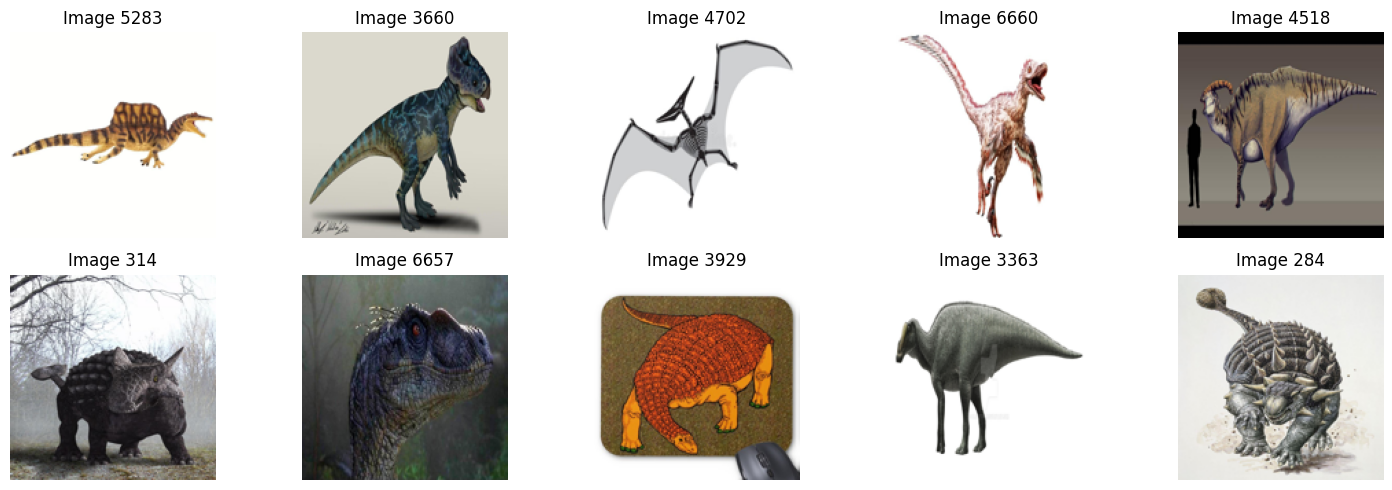

In [3]:
import random
import matplotlib.pyplot as plt

num_show = 10

indices = random.sample(range(len(dino_images)), num_show)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(dino_images[idx])
    plt.axis('off')
    plt.title(f"Image {idx}")

plt.tight_layout()
plt.show()

Завантаження 'Не динозаврів'

In [4]:
from PIL import Image, UnidentifiedImageError

not_dino_paths = glob("dataset/not_dinosaur/**/*.*", recursive=True)
not_dino_images = []

for path in tqdm(not_dino_paths, desc="Завантаження не-динозаврів"):
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        not_dino_images.append(np.array(img))
    except (UnidentifiedImageError, OSError):
        print(f"Пропускаємо файл: {path}")

not_dino_images = np.array(not_dino_images)
not_dino_labels = np.zeros(len(not_dino_images), dtype=np.int32)

print("Готово! Завантажено не-динозаврів:", not_dino_images.shape)


Завантаження не-динозаврів:  32%|███▏      | 2550/8026 [01:03<01:13, 74.56it/s] 

Пропускаємо файл: dataset/not_dinosaur\Dog\Thumbs.db


Завантаження не-динозаврів: 100%|██████████| 8026/8026 [02:25<00:00, 55.16it/s] 


Готово! Завантажено не-динозаврів: (8025, 150, 150, 3)


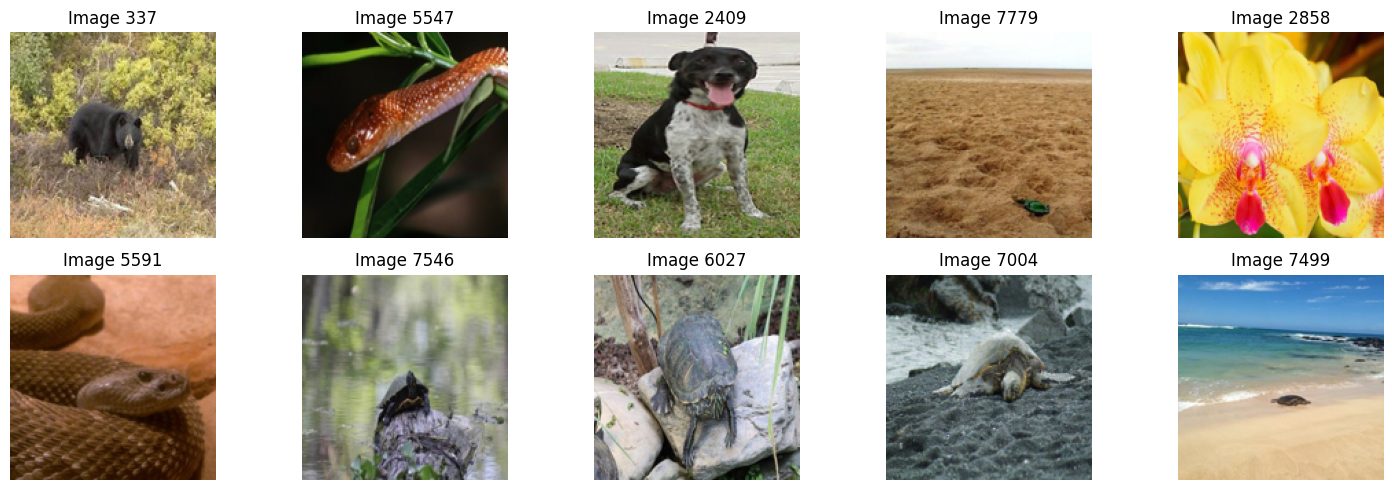

In [5]:
import random
import matplotlib.pyplot as plt

num_show = 10

indices = random.sample(range(len(not_dino_images)), num_show)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(not_dino_images[idx])
    plt.axis('off')
    plt.title(f"Image {idx}")

plt.tight_layout()
plt.show()

Створення фінального дадасету

In [6]:
X = np.concatenate([dino_images, not_dino_images], axis=0).astype("float32") / 255.0
y = np.concatenate([dino_labels, not_dino_labels], axis=0)

print("Фінальний датасет:", X.shape, y.shape)

Фінальний датасет: (14715, 150, 150, 3) (14715,)


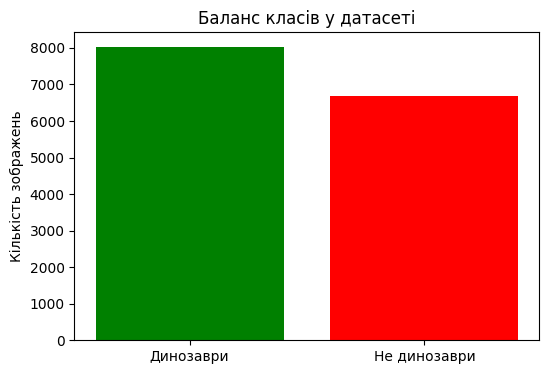

Клас 0: 8025 зображень
Клас 1: 6690 зображень


In [7]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(['Динозаври', 'Не динозаври'], counts, color=['green', 'red'])
plt.title("Баланс класів у датасеті")
plt.ylabel("Кількість зображень")
plt.show()

for u, c in zip(unique, counts):
    print(f"Клас {u}: {c} зображень")

Підготовка даних до навчання

In [8]:
num_samples = len(X)
indices = np.arange(num_samples)
np.random.shuffle(indices)

num_initial = int(INITIAL_LABELED_RATIO * num_samples)
labeled_idx = indices[:num_initial]
unlabeled_idx = indices[num_initial:]

X_labeled = X[labeled_idx]
y_labeled = y[labeled_idx]

X_unlabeled = X[unlabeled_idx]
y_unlabeled = y[unlabeled_idx]

Створення генераторів

In [9]:
train_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
val_gen = ImageDataGenerator()

Створення CNN моделі

In [10]:
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizers.Adam(LEARNING_RATE),
        metrics=['accuracy']
    )
    return model

Функція активного навчання

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall, AUC

def active_learning(model, X_labeled, y_labeled, X_unlabeled, y_unlabeled, 
                    iterations=10, step_ratio=0.01, epochs=EPOCHS, diversity=True):

    # Повний набір метрик
    all_history = {
        "accuracy": [], "val_accuracy": [],
        "loss": [], "val_loss": [],
        "precision": [], "val_precision": [],
        "recall": [], "val_recall": [],
        "auc": [], "val_auc": []
    }

    # Перекомпілюємо модель з новими метриками
    model.compile(
        optimizer=optimizers.Adam(LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            Precision(name="precision"),
            Recall(name="recall"),
            AUC(name="auc")
        ]
    )

    for i in range(iterations):
        print(f"\n=== Ітерація {i+1}/{iterations} ===")

        # Розділення тренувальних та валідаційних даних
        X_train, X_val, y_train, y_val = train_test_split(
            X_labeled, y_labeled, test_size=0.2, random_state=42, stratify=y_labeled
        )

        # Ваги класів
        classes = np.unique(y_train)
        class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weights = {cls: w for cls, w in zip(classes, class_weights_array)}

        # Генератори даних
        train_flow = train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE)
        val_flow = val_gen.flow(X_val, y_val, batch_size=BATCH_SIZE)

        # Навчання моделі з ранньою зупинкою
        history = model.fit(
            train_flow,
            validation_data=val_flow,
            epochs=epochs,
            class_weight=class_weights,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
            verbose=2
        )

        # Запис історії всіх метрик
        for key in history.history.keys():
            if key in all_history:
                all_history[key].extend(history.history[key])

        # Якщо немає немаркованих — завершуємо
        if len(X_unlabeled) == 0:
            print("Немає більше немаркованих даних")
            break

        # Обчислення невпевненості (найближчі до 0.5)
        preds = model.predict(X_unlabeled, batch_size=BATCH_SIZE).flatten()
        uncertainty = np.abs(preds - 0.5)

        # кількість вибраних зразків
        k = max(1, int(step_ratio * len(X_unlabeled)))

        # кандидати (uncertain top-k*5)
        uncertain_idx = np.argsort(uncertainty)[:k * 5]

        # Диверсифікація вибірки через KMeans
        if diversity:
            X_candidates = X_unlabeled[uncertain_idx].reshape(len(uncertain_idx), -1)
            n_clusters = min(k, len(uncertain_idx))
            kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X_candidates)

            diverse_idx = []
            for center in kmeans.cluster_centers_:
                distances = np.linalg.norm(X_candidates - center, axis=1)
                idx = np.argmin(distances)
                diverse_idx.append(uncertain_idx[idx])

            selected_idx = np.array(diverse_idx)
        else:
            selected_idx = uncertain_idx[:k]

        # Додаємо відібрані дані до маркованих
        X_labeled = np.concatenate([X_labeled, X_unlabeled[selected_idx]], axis=0)
        y_labeled = np.concatenate([y_labeled, y_unlabeled[selected_idx]], axis=0)

        # Видаляємо їх з немаркованих
        X_unlabeled = np.delete(X_unlabeled, selected_idx, axis=0)
        y_unlabeled = np.delete(y_unlabeled, selected_idx, axis=0)

        print(f"Додано {len(selected_idx)} нових невпевнених даних. "
              f"Залишилось немаркованих: {len(X_unlabeled)}")

    return all_history


Запуск

In [12]:
cnn_model = create_model() 
history = active_learning(cnn_model, X_labeled, y_labeled, X_unlabeled, y_unlabeled, iterations=20, step_ratio=ACTIVE_LEARNING_STEP)
cnn_model.save(MODEL_PATH)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Ітерація 1/20 ===


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
111/111 - 44s - 393ms/step - accuracy: 0.6069 - auc: 0.6717 - loss: 0.6372 - precision: 0.5621 - recall: 0.6188 - val_accuracy: 0.7339 - val_auc: 0.8125 - val_loss: 0.5443 - val_precision: 0.7114 - val_recall: 0.6990
Epoch 2/5
111/111 - 37s - 337ms/step - accuracy: 0.7077 - auc: 0.7711 - loss: 0.5675 - precision: 0.6851 - recall: 0.6629 - val_accuracy: 0.7576 - val_auc: 0.8534 - val_loss: 0.4926 - val_precision: 0.7207 - val_recall: 0.7637
Epoch 3/5
111/111 - 37s - 336ms/step - accuracy: 0.7253 - auc: 0.8012 - loss: 0.5346 - precision: 0.7088 - recall: 0.6735 - val_accuracy: 0.7792 - val_auc: 0.8682 - val_loss: 0.4674 - val_precision: 0.7620 - val_recall: 0.7488
Epoch 4/5
111/111 - 38s - 346ms/step - accuracy: 0.7485 - auc: 0.8224 - loss: 0.5111 - precision: 0.7368 - recall: 0.6965 - val_accuracy: 0.7678 - val_auc: 0.8687 - val_loss: 0.4703 - val_precision: 0.7194 - val_recall: 0.8035
Epoch 5/5
111/111 - 39s - 348ms/step - accuracy: 0.7533 - auc: 0.8291 - loss: 0.5015 - preci

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

Epoch 1/5
186/186 - 84s - 450ms/step - accuracy: 0.8359 - auc: 0.9175 - loss: 0.3621 - precision: 0.8178 - recall: 0.8097 - val_accuracy: 0.8366 - val_auc: 0.9349 - val_loss: 0.3760 - val_precision: 0.7624 - val_recall: 0.9160
Epoch 2/5
186/186 - 78s - 420ms/step - accuracy: 0.8362 - auc: 0.9218 - loss: 0.3533 - precision: 0.8108 - recall: 0.8219 - val_accuracy: 0.8427 - val_auc: 0.9365 - val_loss: 0.3620 - val_precision: 0.7769 - val_recall: 0.9038
Epoch 3/5
186/186 - 77s - 415ms/step - accuracy: 0.8386 - auc: 0.9215 - loss: 0.3542 - precision: 0.8146 - recall: 0.8227 - val_accuracy: 0.8244 - val_auc: 0.9404 - val_loss: 0.3921 - val_precision: 0.7343 - val_recall: 0.9450
Epoch 4/5
186/186 - 75s - 404ms/step - accuracy: 0.8357 - auc: 0.9222 - loss: 0.3522 - precision: 0.8129 - recall: 0.8169 - val_accuracy: 0.8339 - val_auc: 0.9300 - val_loss: 0.3603 - val_precision: 0.7767 - val_recall: 0.8763
Epoch 5/5
186/186 - 76s - 409ms/step - accuracy: 0.8423 - auc: 0.9246 - loss: 0.3476 - preci

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
189/189 - 73s - 389ms/step - accuracy: 0.8409 - auc: 0.9203 - loss: 0.3558 - precision: 0.8155 - recall: 0.8262 - val_accuracy: 0.8371 - val_auc: 0.9349 - val_loss: 0.3723 - val_precision: 0.7599 - val_recall: 0.9219
Epoch 2/5
189/189 - 74s - 393ms/step - accuracy: 0.8487 - auc: 0.9262 - loss: 0.3437 - precision: 0.8267 - recall: 0.8311 - val_accuracy: 0.8318 - val_auc: 0.9453 - val_loss: 0.3896 - val_precision: 0.7379 - val_recall: 0.9595
Epoch 3/5
189/189 - 87s - 461ms/step - accuracy: 0.8513 - auc: 0.9300 - loss: 0.3364 - precision: 0.8292 - recall: 0.8348 - val_accuracy: 0.8695 - val_auc: 0.9466 - val_loss: 0.3264 - val_precision: 0.8173 - val_recall: 0.9069
Epoch 4/5
189/189 - 75s - 398ms/step - accuracy: 0.8523 - auc: 0.9318 - loss: 0.3335 - precision: 0.8308 - recall: 0.8352 - val_accuracy: 0.8715 - val_auc: 0.9469 - val_loss: 0.3185 - val_precision: 0.8251 - val_recall: 0.8994
Epoch 5/5
189/189 - 71s - 375ms/step - accuracy: 0.8573 - auc: 0.9342 - loss: 0.3273 - preci

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
193/193 - 104s - 536ms/step - accuracy: 0.8526 - auc: 0.9315 - loss: 0.3322 - precision: 0.8286 - recall: 0.8375 - val_accuracy: 0.8499 - val_auc: 0.9433 - val_loss: 0.3489 - val_precision: 0.7727 - val_recall: 0.9319
Epoch 2/5
193/193 - 92s - 478ms/step - accuracy: 0.8559 - auc: 0.9341 - loss: 0.3264 - precision: 0.8289 - recall: 0.8464 - val_accuracy: 0.8356 - val_auc: 0.9438 - val_loss: 0.3823 - val_precision: 0.7448 - val_recall: 0.9511
Epoch 3/5
193/193 - 88s - 456ms/step - accuracy: 0.8603 - auc: 0.9346 - loss: 0.3250 - precision: 0.8418 - recall: 0.8393 - val_accuracy: 0.8616 - val_auc: 0.9494 - val_loss: 0.3322 - val_precision: 0.7939 - val_recall: 0.9244
Epoch 4/5
193/193 - 93s - 481ms/step - accuracy: 0.8565 - auc: 0.9347 - loss: 0.3270 - precision: 0.8330 - recall: 0.8419 - val_accuracy: 0.7765 - val_auc: 0.9386 - val_loss: 0.4745 - val_precision: 0.6687 - val_recall: 0.9719
Epoch 5/5
193/193 - 83s - 431ms/step - accuracy: 0.8593 - auc: 0.9387 - loss: 0.3153 - prec

Візуалізація

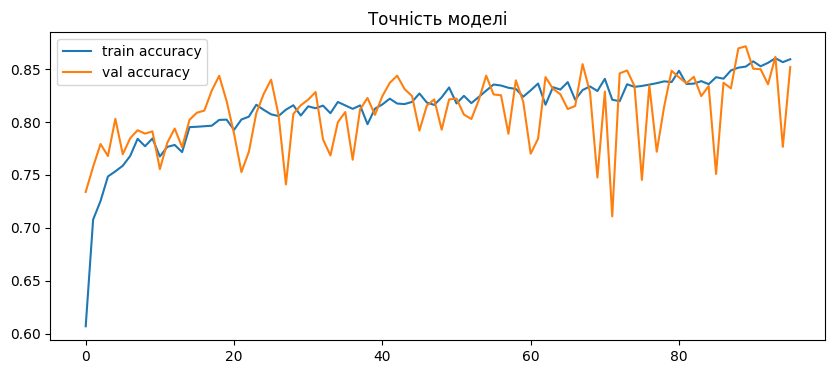

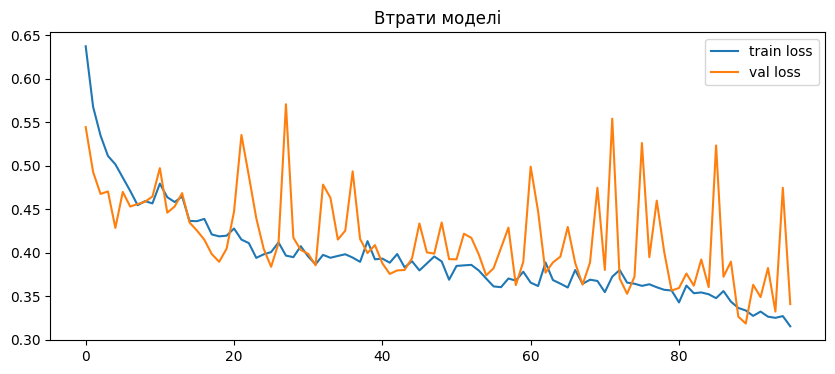

In [13]:
plt.figure(figsize=(10,4))
plt.plot(history["accuracy"], label="train accuracy")
plt.plot(history["val_accuracy"], label="val accuracy")
plt.legend()
plt.title("Точність моделі")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.legend()
plt.title("Втрати моделі")
plt.show()

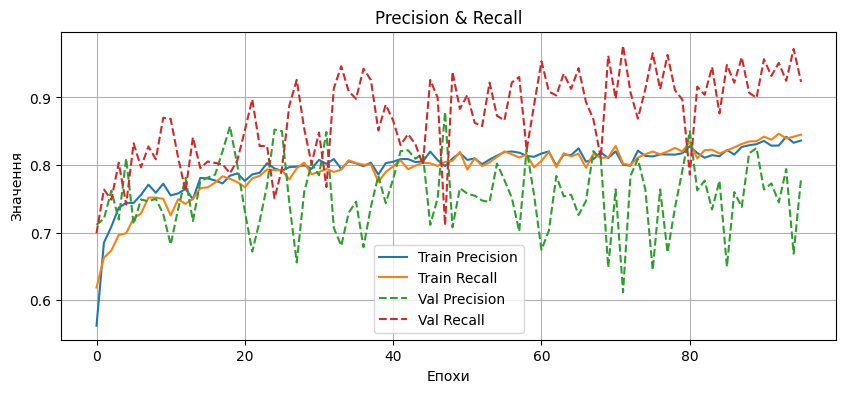

In [14]:
plt.figure(figsize=(10, 4))

plt.plot(history["precision"], label="Train Precision")
plt.plot(history["recall"], label="Train Recall")
plt.plot(history["val_precision"], label="Val Precision", linestyle="--")
plt.plot(history["val_recall"], label="Val Recall", linestyle="--")

plt.legend()
plt.title("Precision & Recall")
plt.xlabel("Епохи")
plt.ylabel("Значення")
plt.grid(True)
plt.show()

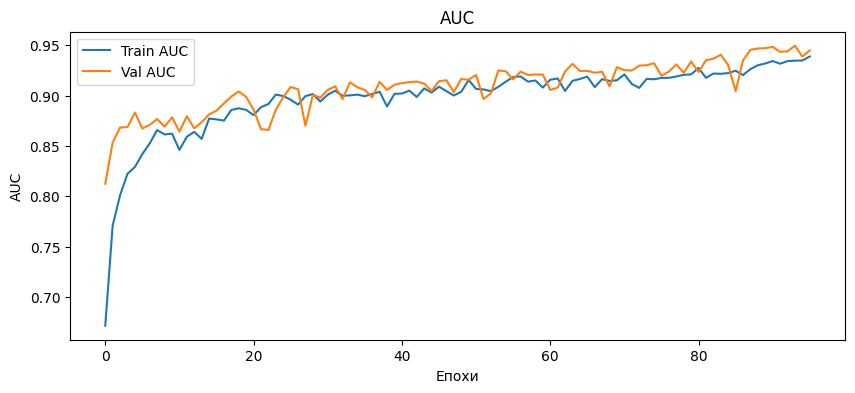

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history["auc"], label="Train AUC")
plt.plot(history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC")
plt.xlabel("Епохи")
plt.ylabel("AUC")
plt.show()

322/322 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step


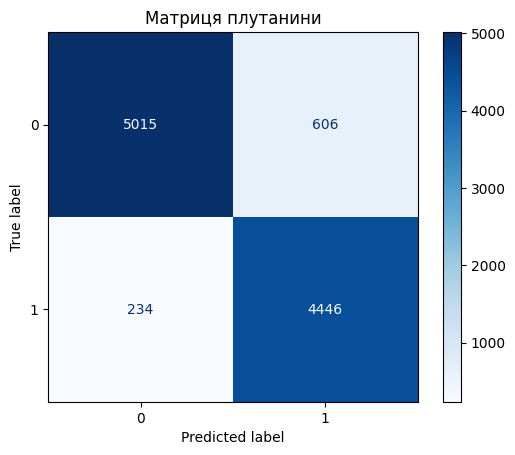

In [16]:
# Передбачення
y_pred = (cnn_model.predict(X_unlabeled) > 0.5).astype(int).flatten()

# Матриця плутанини
cm = confusion_matrix(y_unlabeled, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Матриця плутанини")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


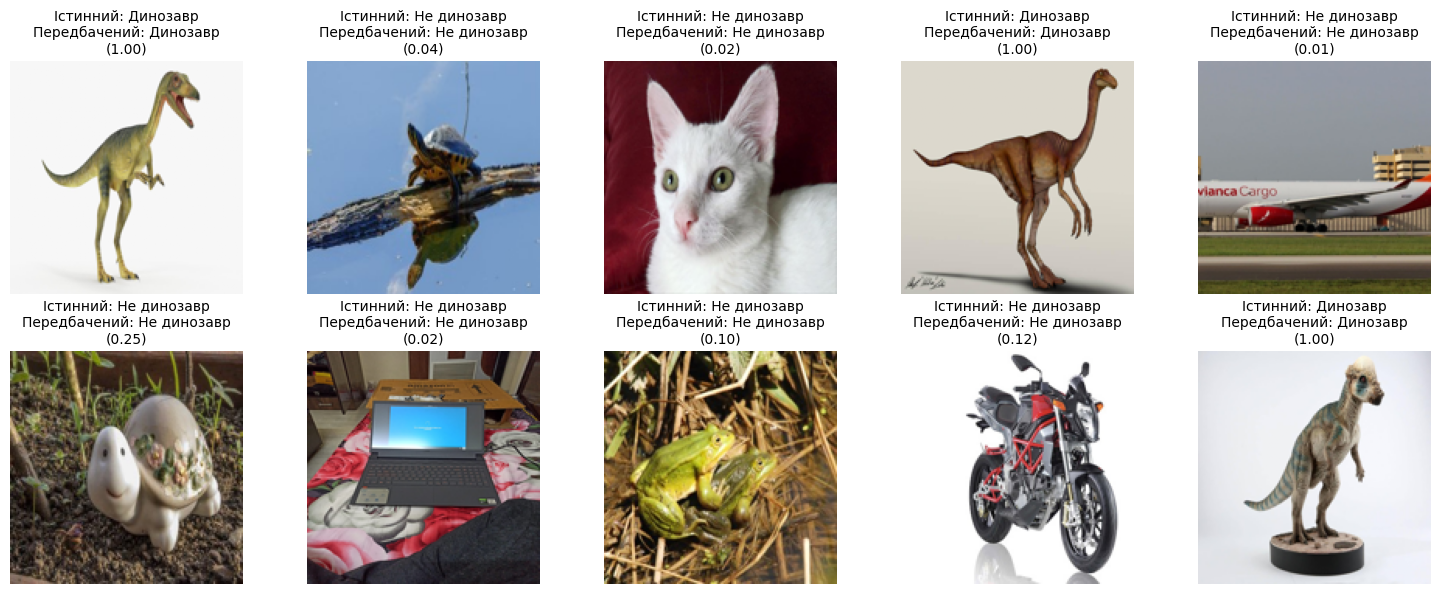

In [17]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

class_names = ["Не динозавр", "Динозавр"]

indices = random.sample(range(len(X_unlabeled)), 10)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    img_orig = (X_unlabeled[idx]*255).astype(np.uint8)
    img_pil = Image.fromarray(img_orig)
    
    img = np.array(img_pil).astype("float32") / 255.0

    true_label = int(y_unlabeled[idx])
    pred = cnn_model.predict(img.reshape(1,150,150,3))[0][0] 
    pred_label = int(pred >= 0.5)  

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Істинний: {class_names[true_label]}\nПередбачений: {class_names[pred_label]}\n({pred:.2f})", fontsize=10)

plt.tight_layout()
plt.show()
